In [16]:
from state import State
from nodes import billing_node, general_inquiry_node, route_issue, technical_support_node
from langgraph.graph import StateGraph, START, END




def check_route(state: State) -> str:
    route_to = state["route_to"]
    if route_to == "Technical Support":
        return "Technical Support Node"
    elif route_to == "Billing":
        return "Billing Node"
    else:
        return "General Inquiry Node"

graph = StateGraph(State)

graph.add_node("Route Issue", route_issue)
graph.add_node("Technical Support Node", technical_support_node)
graph.add_node("Billing Node", billing_node)
graph.add_node("General Inquiry Node", general_inquiry_node)


graph.add_edge(START, "Route Issue")
graph.add_conditional_edges(
    "Route Issue", check_route,{
        "Technical Support Node": "Technical Support Node",
        "Billing Node": "Billing Node",
        "General Inquiry Node": "General Inquiry Node"
    })
graph.add_edge("Technical Support Node", END)
graph.add_edge("Billing Node", END)
graph.add_edge("General Inquiry Node", END)

app = graph.compile()

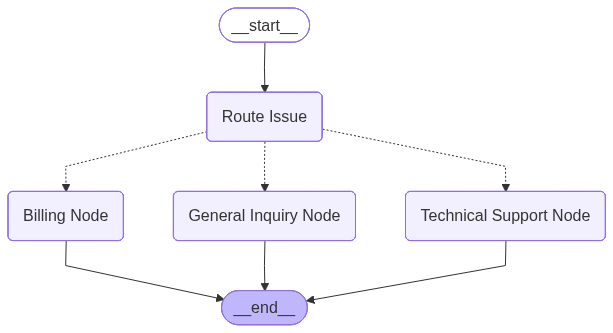

In [17]:
app